# PDAC Epithelial Remodeling — SampleCLR Tutorial

This notebook covers the full SampleCLR analysis pipeline for PDAC epithelial cells.

**Starting assumption:** The preprocessed AnnData object already exists at  
`/workspace/hpca/hpca_downstream/PDAC_Results/hpca_pdac_epithelial_counts.h5ad` and contains:
- Raw counts in `adata.layers['counts']` and log-normalized expression in `adata.X`
- Harmonized metadata: `Final_Labels`, `Dataset_ID`, `Condition`, `suspension_type_harmonized`, `age_category`
- SCVI/SCANVI latent representations in `adata.obsm['X_scanvi']` and UMAP in `adata.obsm['X_umap']`

**Workflow:**
1. Imports & helper functions
2. SampleCLR training (self-supervised → fine-tuned)
3. Sample-level embedding analysis and UMAP
4. Pseudotime trajectory inference (DPT)
5. Leiden clustering, PAGA, and Visualization Axes
6. Pseudobulk construction
7. Branch-specific gene–pseudotime correlations


## 1. Imports

Import all libraries used throughout the notebook.


In [ ]:
import os

# Set GITHUB_TOKEN in your environment before running this cell (do not hardcode tokens).
# Colab example: os.environ["GITHUB_TOKEN"] = userdata.get("GITHUB_TOKEN")
if not os.environ.get("GITHUB_TOKEN"):
    raise ValueError("GITHUB_TOKEN must be set in the environment before running this cell.")

!pip install --no-cache-dir "git+https://${GITHUB_TOKEN}@github.com/lueckenlab/SampleCLR.git@bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0"
!pip install patpy

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import patpy
from patpy.tl import associate_embedding_with_covariates
from patpy.pl import embedding_covariate_heatmap
import sampleclr
from sampleclr.utils import (
    get_sample_representations_from_adata,
    _compute_eigenvector_centrality,
    plot_losses,
)


/opt/scanpy_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import re
import yaml
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from scipy import sparse
from scipy.stats import mannwhitneyu, spearmanr, entropy
from tqdm import tqdm
import anndata as ad


### 1.1 Helper: Cell Attention Weights

This function extracts per-cell attention weights from the trained SampleCLR model, 
revealing which cells each sample-level representation focuses on most strongly.


In [4]:
@torch.no_grad()
def get_cell_attention_weights(model, adata, sample_key, layer, device="cpu"):
    """Returns (n_cells, n_heads) array, aligned with adata.obs_names."""
    import scipy.sparse as sp

    # Flip aggregator into weight-returning eval mode
    old_rw = model.aggregator.return_weights
    was_train = model.aggregator.training
    model.projector.to(device).eval()
    model.aggregator.to(device).eval()
    model.aggregator.return_weights = True

    samples = adata.obs[sample_key].unique()
    all_w, all_idx = [], []

    for s in samples:
        mask = (adata.obs[sample_key] == s).values
        if not mask.any():
            continue
        feats = adata[mask].obsm[layer] if layer != "X" else adata[mask].X
        if sp.issparse(feats):  
            feats = np.asarray(feats.todense())
        x = torch.tensor(np.asarray(feats), dtype=torch.float32).unsqueeze(0).to(device)
        # aggregator returns (pooled_emb, weights); shape: (1, n_cells_in_sample, n_heads)
        _, w = model.aggregator(x)
        all_w.append(w.squeeze(0).cpu().numpy())
        all_idx.append(np.where(mask)[0])

    n_heads = all_w[0].shape[1]
    weights = np.zeros((adata.n_obs, n_heads), dtype=np.float32)
    for w, idx in zip(all_w, all_idx):
        weights[idx] = w

    # Restore aggregator state
    model.aggregator.return_weights = old_rw
    model.aggregator.train(was_train)
    return weights


## 2. SampleCLR: Sample-Level Contrastive Learning

SampleCLR learns a low-dimensional embedding for each *sample* (donor) by:
1. Aggregating cell-level SCVI latent representations within each sample
2. Training with a contrastive objective that pulls together cells from the same condition
3. Fine-tuning with a supervised signal from known condition labels

We use the `X_scanvi` latent space as input, and filter samples with fewer than 250 cells.


In [5]:
import os
os.chdir('workspace/hpca/hpca_downstream/PDAC_Results/')


In [6]:
import scanpy as sc
sc.set_figure_params(frameon=False)


### 2.1 Load AnnData

Load the preprocessed epithelial AnnData object.


In [7]:
adata = sc.read_h5ad('/workspace/hpca/hpca_downstream/PDAC_Results/hpca_pdac_epithelial_counts.h5ad')


In [8]:
adata


AnnData object with n_obs × n_vars = 1020279 × 21730
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

### 2.2 Visualize Cell-Level UMAP

Inspect the integration colored by `Condition` before sample-level training.


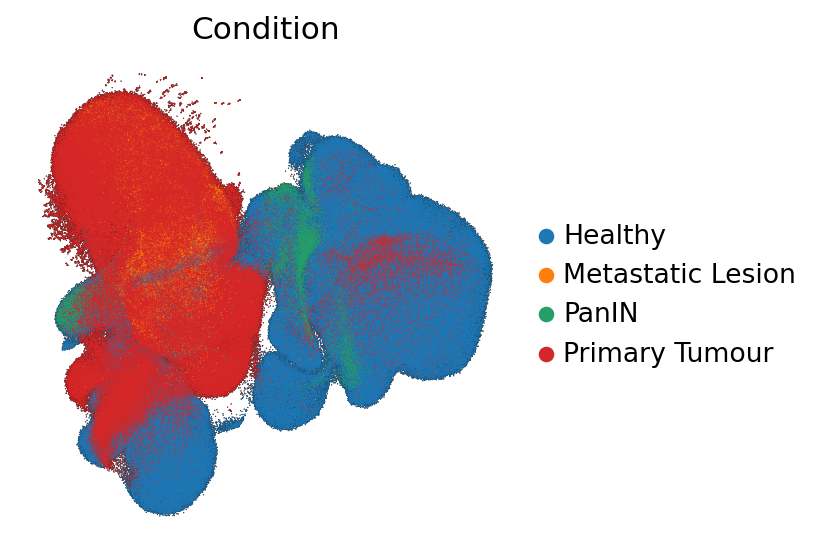

In [9]:
sc.pl.umap(
    adata,
    color=['Condition'],
    legend_fontsize=12,
    size=1,
    sort_order=True,
    groups=None,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.05),
    outline_color=['white', 'black'],
    na_color='lightgray',
    alpha=0.75,
    na_in_legend=False,
)


### 2.3 Key Training Parameters


In [10]:
SAMPLE_KEY = "Dataset_ID"
LAYER = "X_scanvi"
SEED = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### 2.4 Filter Small Samples

Samples with very few cells produce unreliable aggregate representations. 
We visualize the distribution and apply a threshold of **250 cells per sample**.


Text(0.5, 1.0, '280 samples > 250 | 232 samples > 500 | 201 samples > 750 cells')

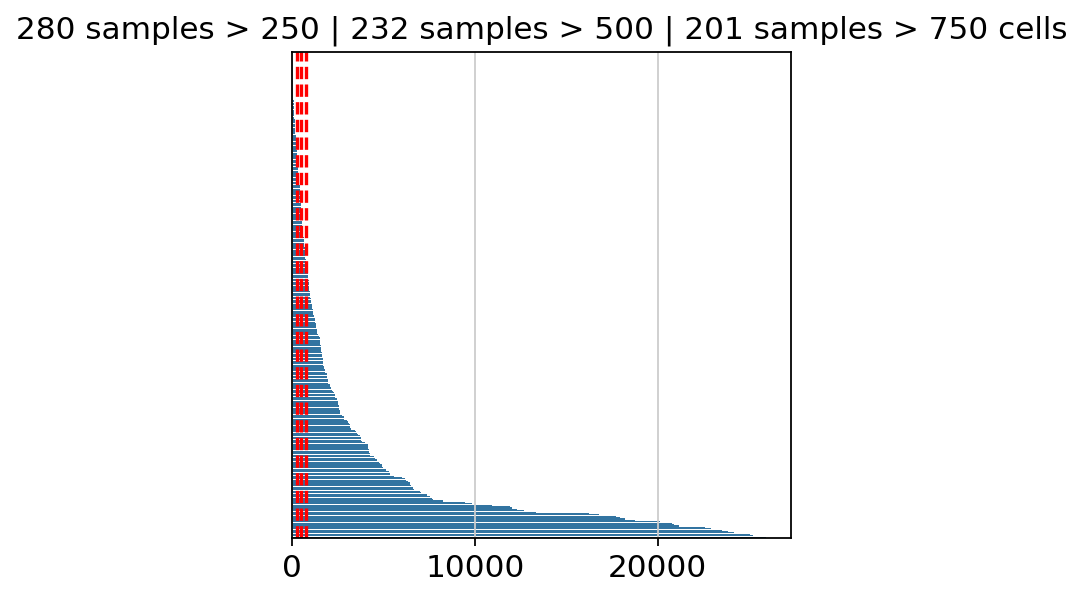

In [11]:
SAMPLE_SIZE_THRESHOLDS = [250, 500, 750]
sample_counts = adata.obs[SAMPLE_KEY].value_counts()
sns.barplot(x=sample_counts.values, y=np.arange(len(sample_counts.index)), orient="h")
plt.yticks([], [])
for thresh in SAMPLE_SIZE_THRESHOLDS:
    plt.vlines(thresh, 0, len(sample_counts.index), colors="red", linestyles="dashed")
plt.ylim(0, len(sample_counts.index))
# Create a composite title showing how many samples are above each threshold
titles = [
    f"{(sample_counts > thresh).sum()} samples > {thresh}"
    for thresh in SAMPLE_SIZE_THRESHOLDS
]
plt.title(" | ".join(titles) + " cells")


In [12]:
SAMPLE_SIZE_THRESHOLD = 250


In [13]:
adata = patpy.pp.filter_small_samples(adata, SAMPLE_KEY, sample_size_threshold=SAMPLE_SIZE_THRESHOLD)
adata


71 samples removed: GSE84133_remapped : H2 [Healthy], HPAP : HPAP-034 [Healthy], GSE150724 : donor_SAMN12227196 [Healthy], GSE84133_remapped : H4 [Healthy], Steele_2020_PDAC_TISSUE : 4 [PDAC], Peng_2019 : N3 [PDAC], Steele_2020_PDAC_TISSUE : 1 [PDAC], Peng_2019 : T10 [PDAC], Karakose : HP21226 [Healthy], HPAP : HPAP-105 [Healthy], GSE101207_remapped : Non_diabetic_donor_4 [Healthy], GSE114297_remapped : Donor-3 [Healthy], Karakose : SAMN1408 [Healthy], HPAP : HPAP-026 [Healthy], GSE84133_remapped : H1 [Healthy], Hwang_2022 : T17 [PDAC], Steele_2020_PDAC_TISSUE : 9 [PDAC], HPAP : HPAP-056 [Healthy], GSE114297_remapped : Donor-4 [Healthy], HPAP : HPAP-077 [Healthy], GSE101207_remapped : Non_diabetic_donor_1 [Healthy], Steele_2020_PDAC_TISSUE : 11B [PDAC], HPAP : HPAP-052 [Healthy], Kemp_2020 : LiverMetA [PDAC], GSE114297_remapped : Donor-1 [Healthy], HPAP : HPAP-080 [Healthy], HPAP : HPAP-022 [Healthy], GSE114297_remapped : Donor-11 [Healthy], GSE101207_remapped : Non_diabetic_donor_5 [H

AnnData object with n_obs × n_vars = 1013509 × 21730
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top

In [14]:
print(adata.obs.Condition.value_counts())
adata.obs.groupby('Condition')['Dataset_ID'].nunique()


Condition
Healthy              555988
Primary Tumour       396751
Metastatic Lesion     47744
PanIN                 13026
Name: count, dtype: int64


/tmp/ipykernel_270359/1990147221.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Condition')['Dataset_ID'].nunique()


Condition
Healthy               85
Metastatic Lesion     22
PanIN                  4
Primary Tumour       169
Name: Dataset_ID, dtype: int64

### 2.5 Train/Validation Split

We split at the **sample level** (not cell level) to avoid data leakage — all cells from 
a given donor belong to either train or val, never both.


In [15]:
# ---- 2.5 Train/val split at the SAMPLE level ----------------------------
all_ids = adata.obs[SAMPLE_KEY].unique()
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=SEED)
print(f"Train samples: {len(train_ids)}, Val samples: {len(val_ids)}")


Train samples: 224, Val samples: 56


### 2.6 Prepare Sample Metadata

Extract per-sample metadata used as supervision signal during fine-tuning.


In [16]:
# Harmonize suspension type
adata.obs['suspension_type_harmonized'] = np.nan  # initialize
mask_scrna = adata.obs['Technology'].astype(str).str.startswith('scRNA', na=False)
mask_snrna = adata.obs['Technology'].astype(str).str.startswith('snRNA', na=False)
mask_cell = adata.obs['suspension_type'].astype(str).str.startswith('cell', na=False)
mask_nuc = adata.obs['suspension_type'].astype(str).str.startswith('nuc', na=False)

adata.obs.loc[mask_scrna, 'suspension_type_harmonized'] = 'cell'
adata.obs.loc[mask_snrna, 'suspension_type_harmonized'] = 'nucleus'
adata.obs.loc[mask_cell, 'suspension_type_harmonized'] = 'cell'
adata.obs.loc[mask_nuc, 'suspension_type_harmonized'] = 'nucleus'

adata.obs['Disease'] = adata.obs.condition.copy()


/tmp/ipykernel_270359/1686716136.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cell' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[mask_scrna, 'suspension_type_harmonized'] = 'cell'


In [17]:
sample_level_columns = [
 'Dataset',
 'sample_id', 
 'Condition',
 'condition',
 'manner_of_death',
 'suspension_type', 'suspension_type_harmonized',
 'technology',
 'assay', 'Age', 'Sex',
 'Disease',
 'gene_annotation_version',
 'batch_covar_split',
 'batch_covariate',
 'batch_covar_final',
 'Treatment', 'TreatmentType']


In [18]:
sample_ids = adata.obs.Dataset_ID.unique()


In [19]:
metadata = patpy.pp.extract_metadata(
    adata,
    sample_key=SAMPLE_KEY,
    columns=sample_level_columns,
    samples=sample_ids
)
metadata


/tmp/ipykernel_270359/2281487140.py:1: UserWarning: Metadata contains multiple values for the same sample, taking only the first occurence
  metadata = patpy.pp.extract_metadata(


,Dataset,sample_id,Condition,condition,manner_of_death,suspension_type,suspension_type_harmonized,technology,assay,Age,Sex,Disease,gene_annotation_version,batch_covar_split,batch_covariate,batch_covar_final,Treatment,TreatmentType
Dataset_ID,,,,,,,,,,,,,,,,,,
GSE84133_remapped : H3 [Healthy],GSE84133_remapped,H3_pancreas,Healthy,Healthy,unknown,cell,cell,NaN,inDrop,NaN,NaN,Healthy,NaN,GSE84133_remapped,H3_pancreas,GSE84133_remapped,NaN,NaN
GSE183568 : SAMN08768781 [Healthy],GSE183568,islet_specimen_3,Healthy,Healthy,unknown,cell,cell,NaN,10x 3′ v2,NaN,NaN,Healthy,NaN,GSE183568,GSE183568,GSE183568,NaN,NaN
GSE183568 : SAMN08768783 [Healthy],GSE183568,islet_specimen_4,Healthy,Healthy,unknown,cell,cell,NaN,10x 3′ v2,NaN,NaN,Healthy,NaN,GSE183568,GSE183568,GSE183568,NaN,NaN
GSE183568 : R232 [Healthy],GSE183568,islet_specimen_5,Healthy,Healthy,unknown,cell,cell,NaN,10x 3′ v2,NaN,NaN,Healthy,NaN,GSE183568,GSE183568,GSE183568,NaN,NaN
GSE183568 : DON184 [Healthy],GSE183568,islet_specimen_1,Healthy,Healthy,unknown,cell,cell,NaN,10x 3′ v2,NaN,NaN,Healthy,NaN,GSE183568,GSE183568,GSE183568,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yue_2020 : 95092 [PDAC],Yue_2020,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,Unknown,Unknown,PDAC,NaN,Yue_2020_95092,NaN,NaN,Untreated,Untreated
Yue_2020 : 95373 [PDAC],Yue_2020,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,Unknown,Unknown,PDAC,NaN,Yue_2020_95373,NaN,NaN,Untreated,Untreated
Yue_2020 : 96460 [PDAC],Yue_2020,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,Unknown,Unknown,PDAC,NaN,Yue_2020_96460,NaN,NaN,Untreated,Untreated


### 2.7 Self-Supervised Pre-training

Initialise and pre-train the `ContrastiveModel` using only the contrastive objective (no labels). 
This learns a representation that clusters samples by their transcriptional similarity.


In [20]:
model = sampleclr.ContrastiveModel(
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    train_ids=list(train_ids),
    val_ids=list(val_ids),
    # data sampling
    batch_size=8,
    n_cells_per_sample=[250, 500],   # range; or an int for constant
    # encoder
    hidden_size=128,
    output_dim=128,
    use_concord_sampler=True,
    concord_batch_col="Dataset",
    concord_Pd=0.9,
    num_layers=1,
    # aggregator (multihead attention)
    aggregator_type="multihead",
    aggregator_pooling="attention",
    aggregator_activation="relu",
    aggregator_hidden_size=128,
    aggregator_num_layers=2,
    aggregator_normalization="BatchNorm",
    aggregator_dropout=0.2,
    n_aggregator_heads=4,
    # loss / optim
    contrastive_loss="XSampleCLR",
    contrastive_loss_temperature=0.1,
    learning_rate_feature=3e-4,
    weight_decay=1e-4,
    feature_normalization="BatchNorm",
    # training control
    early_stopping_patience=100,
    num_warmup_epochs_stage1=10,
    num_warmup_epochs_stage2=10,
    seed=SEED,
    attention_sparsity_lambda=1e-5,
    # Supervised fine-tuning tasks
    tasks={"classification": ["Condition"]},
    classifier_num_layers=2,
    classifier_hidden_size=128
)

best_state, best_metric, n_s1, n_s2 = model.train(
    num_epochs_stage1=200,   # SSL contrastive
    num_epochs_stage2=0,     # >0 to add supervised heads (fine-tune)
    stage1_val_metric="loss",
    verbose=True,
)


Using MULTI ANCHOR CONCORD sampler (Pd=0.9, PkNN=0.3, k=3)
  -> 8 anchors/batch, 28 batches/epoch, grouping=random
MultiAnchorConcordSampler: 26 technical batches, 224 valid samples
Computing kNN (k=3, n_samples=224)...
kNN complete in 0.05s
Precomputing quadrants...
Quadrants precomputed in 0.01s
Ready. Targets: ib_knn=1, ib_g=5, ob_knn=0, ob_g=1
Stage 1: Contrastive-only training
Epoch 1/200 - Loss: 1.5453, Contr: 1.5453, Top1: 0.991, Top5: 1.000 | Time: 0.48s (28 batches, 13.0ms/batch)
Full Loss Report:
contrastive – train: 1.5453 – val: 1.1393
classification (Condition) – train: 0.0000 – val: 2.7770
contrastive top1 acc – train: 0.9911 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
Epoch 2/200 - Loss: 1.4470, Contr: 1.4470, Top1: 1.000, Top5: 1.000 | Time: 0.37s (28 batches, 9.9ms/batch)
Full Loss Report:
contrastive – train: 1.4470 – val: 1.0258
classification (Condition) – train: 0.0000 – val: 2.7811
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive

In [21]:
reps = get_sample_representations_from_adata(
    projector=model.projector,
    aggregator=model.aggregator,
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    meta_obs_names=sample_ids,
    subset_size=1000,           # cells per sample at inference
    device=device,
    # cell_selection="eigenvector",   # or "random"
    # eigenvector_col="eigenvector_centrality",
)


### 2.8 Supervised Fine-tuning

Fine-tune with a lower contrastive loss weight (`0.1`), giving more influence to the 
supervised classification head. The best checkpoint is selected by validation metric.


In [22]:
model.contrastive_loss_weight = 0.1  # Decrease to give supervised loss more weight
best_state, best_metric, n_s1, n_s2 = model.train(
    num_epochs_stage1=0,   # SSL contrastive
    num_epochs_stage2=300,     # >0 to add supervised heads (fine-tune)
    stage2_val_metric="loss",
    verbose=True)

try:
    model.load_model(best_state)
except Exception:
    print("Failed to load model's best state")


Using MULTI ANCHOR CONCORD sampler (Pd=0.9, PkNN=0.3, k=3)
  -> 8 anchors/batch, 28 batches/epoch, grouping=random
MultiAnchorConcordSampler: 26 technical batches, 224 valid samples
Computing kNN (k=3, n_samples=224)...
kNN complete in 0.05s
Precomputing quadrants...
Quadrants precomputed in 0.01s
Ready. Targets: ib_knn=1, ib_g=5, ob_knn=0, ob_g=1
Stage 1: Contrastive-only training
Stage joint: training
Freezing the backbone for 10 epochs

Epoch 1/300 | Time: 0.20s (28 batches, 4.0ms/batch)
contrastive – train: 0.0103 – val: 0.0052
classification (Condition) – train: 2.7900 – val: 2.7900
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------

Epoch 2/300 | Time: 0.30s (28 batches, 7.6ms/batch)
contrastive – train: 0.0200 – val: 0.0028
classification (Condition) – train: 2.7843 – val: 2.7852
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------

### 2.9 Extract Fine-tuned Embeddings

Extract sample-level embeddings from the fine-tuned model checkpoint.


In [23]:
# Extract sample-level embeddings --------------------------------
reps_finetuned = get_sample_representations_from_adata(
    projector=model.projector,
    aggregator=model.aggregator,
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    meta_obs_names=sample_ids,
    subset_size=1000,           # cells per sample at inference
    device=device,
    # cell_selection="eigenvector",   # or "random"
    # eigenvector_col="eigenvector_centrality",
)
# reps: (n_samples, output_dim) — one embedding per sample

sample_reps_finetuned = pd.DataFrame(reps_finetuned, index=sample_ids)


In [24]:
sample_reps_finetuned
# can be saved as csv
# sample_reps_finetuned.to_csv('sample_reps_finetuned.csv')


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
GSE84133_remapped : H3 [Healthy],0.098921,0.055825,-0.057171,0.070581,-0.062999,-0.022142,-0.006450,0.032674,0.064328,0.004988,...,0.034904,0.025102,-0.023106,0.021891,0.073527,0.013884,-0.056765,-0.068321,0.082820,0.091632
GSE183568 : SAMN08768781 [Healthy],-0.014831,-0.020365,-0.046808,0.021546,-0.097086,0.032173,0.012068,0.004721,0.087693,0.049791,...,0.034196,0.004728,-0.005984,-0.026185,0.069151,0.070524,-0.053914,-0.021999,0.063362,0.052255
GSE183568 : SAMN08768783 [Healthy],-0.080514,0.002985,-0.007199,-0.089229,-0.005253,0.013148,0.078902,0.010048,0.000999,0.057094,...,-0.000264,-0.037088,0.009963,-0.046354,0.012636,0.055938,-0.061289,0.044225,0.031237,-0.016400
GSE183568 : R232 [Healthy],-0.028228,0.023015,-0.004268,0.005238,-0.074589,-0.010810,0.081411,0.096527,0.031647,0.044600,...,0.009833,-0.004047,-0.051149,0.010959,0.008692,-0.015328,-0.069334,-0.021138,0.090572,0.016196
GSE183568 : DON184 [Healthy],-0.026035,-0.006502,0.024099,-0.096992,0.031623,-0.005376,0.008436,0.007571,-0.015142,0.056988,...,-0.040194,-0.009022,0.045298,-0.007241,-0.031928,0.022069,-0.019876,0.035515,0.019964,0.018742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yue_2020 : 95092 [PDAC],0.031654,-0.013305,0.052072,-0.012397,0.049042,-0.046434,-0.036732,-0.015588,-0.041829,0.042897,...,-0.037385,0.012867,-0.008178,0.013603,0.046087,-0.020041,-0.027976,-0.026835,0.003198,0.001481
Yue_2020 : 95373 [PDAC],0.008029,-0.002141,0.039875,-0.008009,0.036312,-0.018114,-0.008830,-0.003872,-0.041596,0.036517,...,-0.025922,-0.022298,0.001692,0.031341,0.002645,-0.022492,0.013255,-0.006649,-0.013314,-0.024718
Yue_2020 : 96460 [PDAC],-0.016990,-0.008928,0.045916,-0.043959,0.043416,-0.001712,0.008098,0.001906,-0.037542,0.049870,...,-0.020323,-0.006544,0.017590,0.029710,-0.000862,-0.009199,-0.014850,0.013705,-0.010747,-0.037023
Yue_2020 : 97727 [PDAC],0.126131,-0.055955,-0.009011,-0.000207,-0.013081,-0.023858,-0.091263,-0.081145,0.023594,0.143209,...,-0.056398,-0.034669,0.026427,-0.070268,0.096657,-0.044820,-0.000744,-0.054706,-0.076919,0.042416


## 3. Sample-Level Embedding Analysis

We construct a **meta-AnnData** where each *observation* is a **sample (donor)**, not a cell.  
`X_sampleclr_ft` holds the fine-tuned SampleCLR representations, while `.X` contains the cell type composition proportions — enabling standard Scanpy visualization tools.


### 3.1 Build Cell Type Composition Matrix


In [25]:
composition_raw = pd.crosstab(adata.obs['Dataset_ID'], adata.obs['Final_Labels'])
composition_prop = composition_raw.div(composition_raw.sum(axis=1), axis=0) * 100
composition_prop = composition_prop.loc[sample_ids]
composition_raw = composition_raw.loc[sample_ids]


### 3.2 Construct meta_adata


In [26]:
meta_adata = sc.AnnData(obs=metadata.loc[sample_ids], obsm={"X_sampleclr_ssl": reps}, X=composition_prop)
meta_adata.layers['composition_raw'] = composition_raw.copy()
meta_adata.obsm["X_sampleclr_ft"] = sample_reps_finetuned.loc[sample_ids].values
meta_adata


AnnData object with n_obs × n_vars = 280 × 28
    obs: 'Dataset', 'sample_id', 'Condition', 'condition', 'manner_of_death', 'suspension_type', 'suspension_type_harmonized', 'technology', 'assay', 'Age', 'Sex', 'Disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covariate', 'batch_covar_final', 'Treatment', 'TreatmentType'
    obsm: 'X_sampleclr_ssl', 'X_sampleclr_ft'
    layers: 'composition_raw'

### 3.3 Compute Neighbors and UMAP

Run on the fine-tuned SampleCLR embedding to visualize sample-level structure.


In [27]:
sc.pp.neighbors(meta_adata, use_rep="X_sampleclr_ft", key_added="neighbors_sampleclr_ft")
sc.tl.umap(meta_adata, neighbors_key="neighbors_sampleclr_ft")
sc.tl.leiden(meta_adata, resolution=1, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")
sc.tl.diffmap(meta_adata, neighbors_key="neighbors_sampleclr_ft")


/tmp/ipykernel_270359/1018405509.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(meta_adata, resolution=1, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")


In [ ]:
meta_adata.obs['suspension_type_harmonized'] = meta_adata.obs_names.map(dict(zip(adata.obs.Dataset_ID, adata.obs['suspension_type_harmonized'])))

### 3.4 Visualize Sample UMAP

Color by metadata variables to understand the main axes of variation.


In [29]:
cols_to_plot = [
   "Dataset",
    "suspension_type_harmonized",
    "Condition", "Treatment", "TreatmentType", "leiden_ft"]


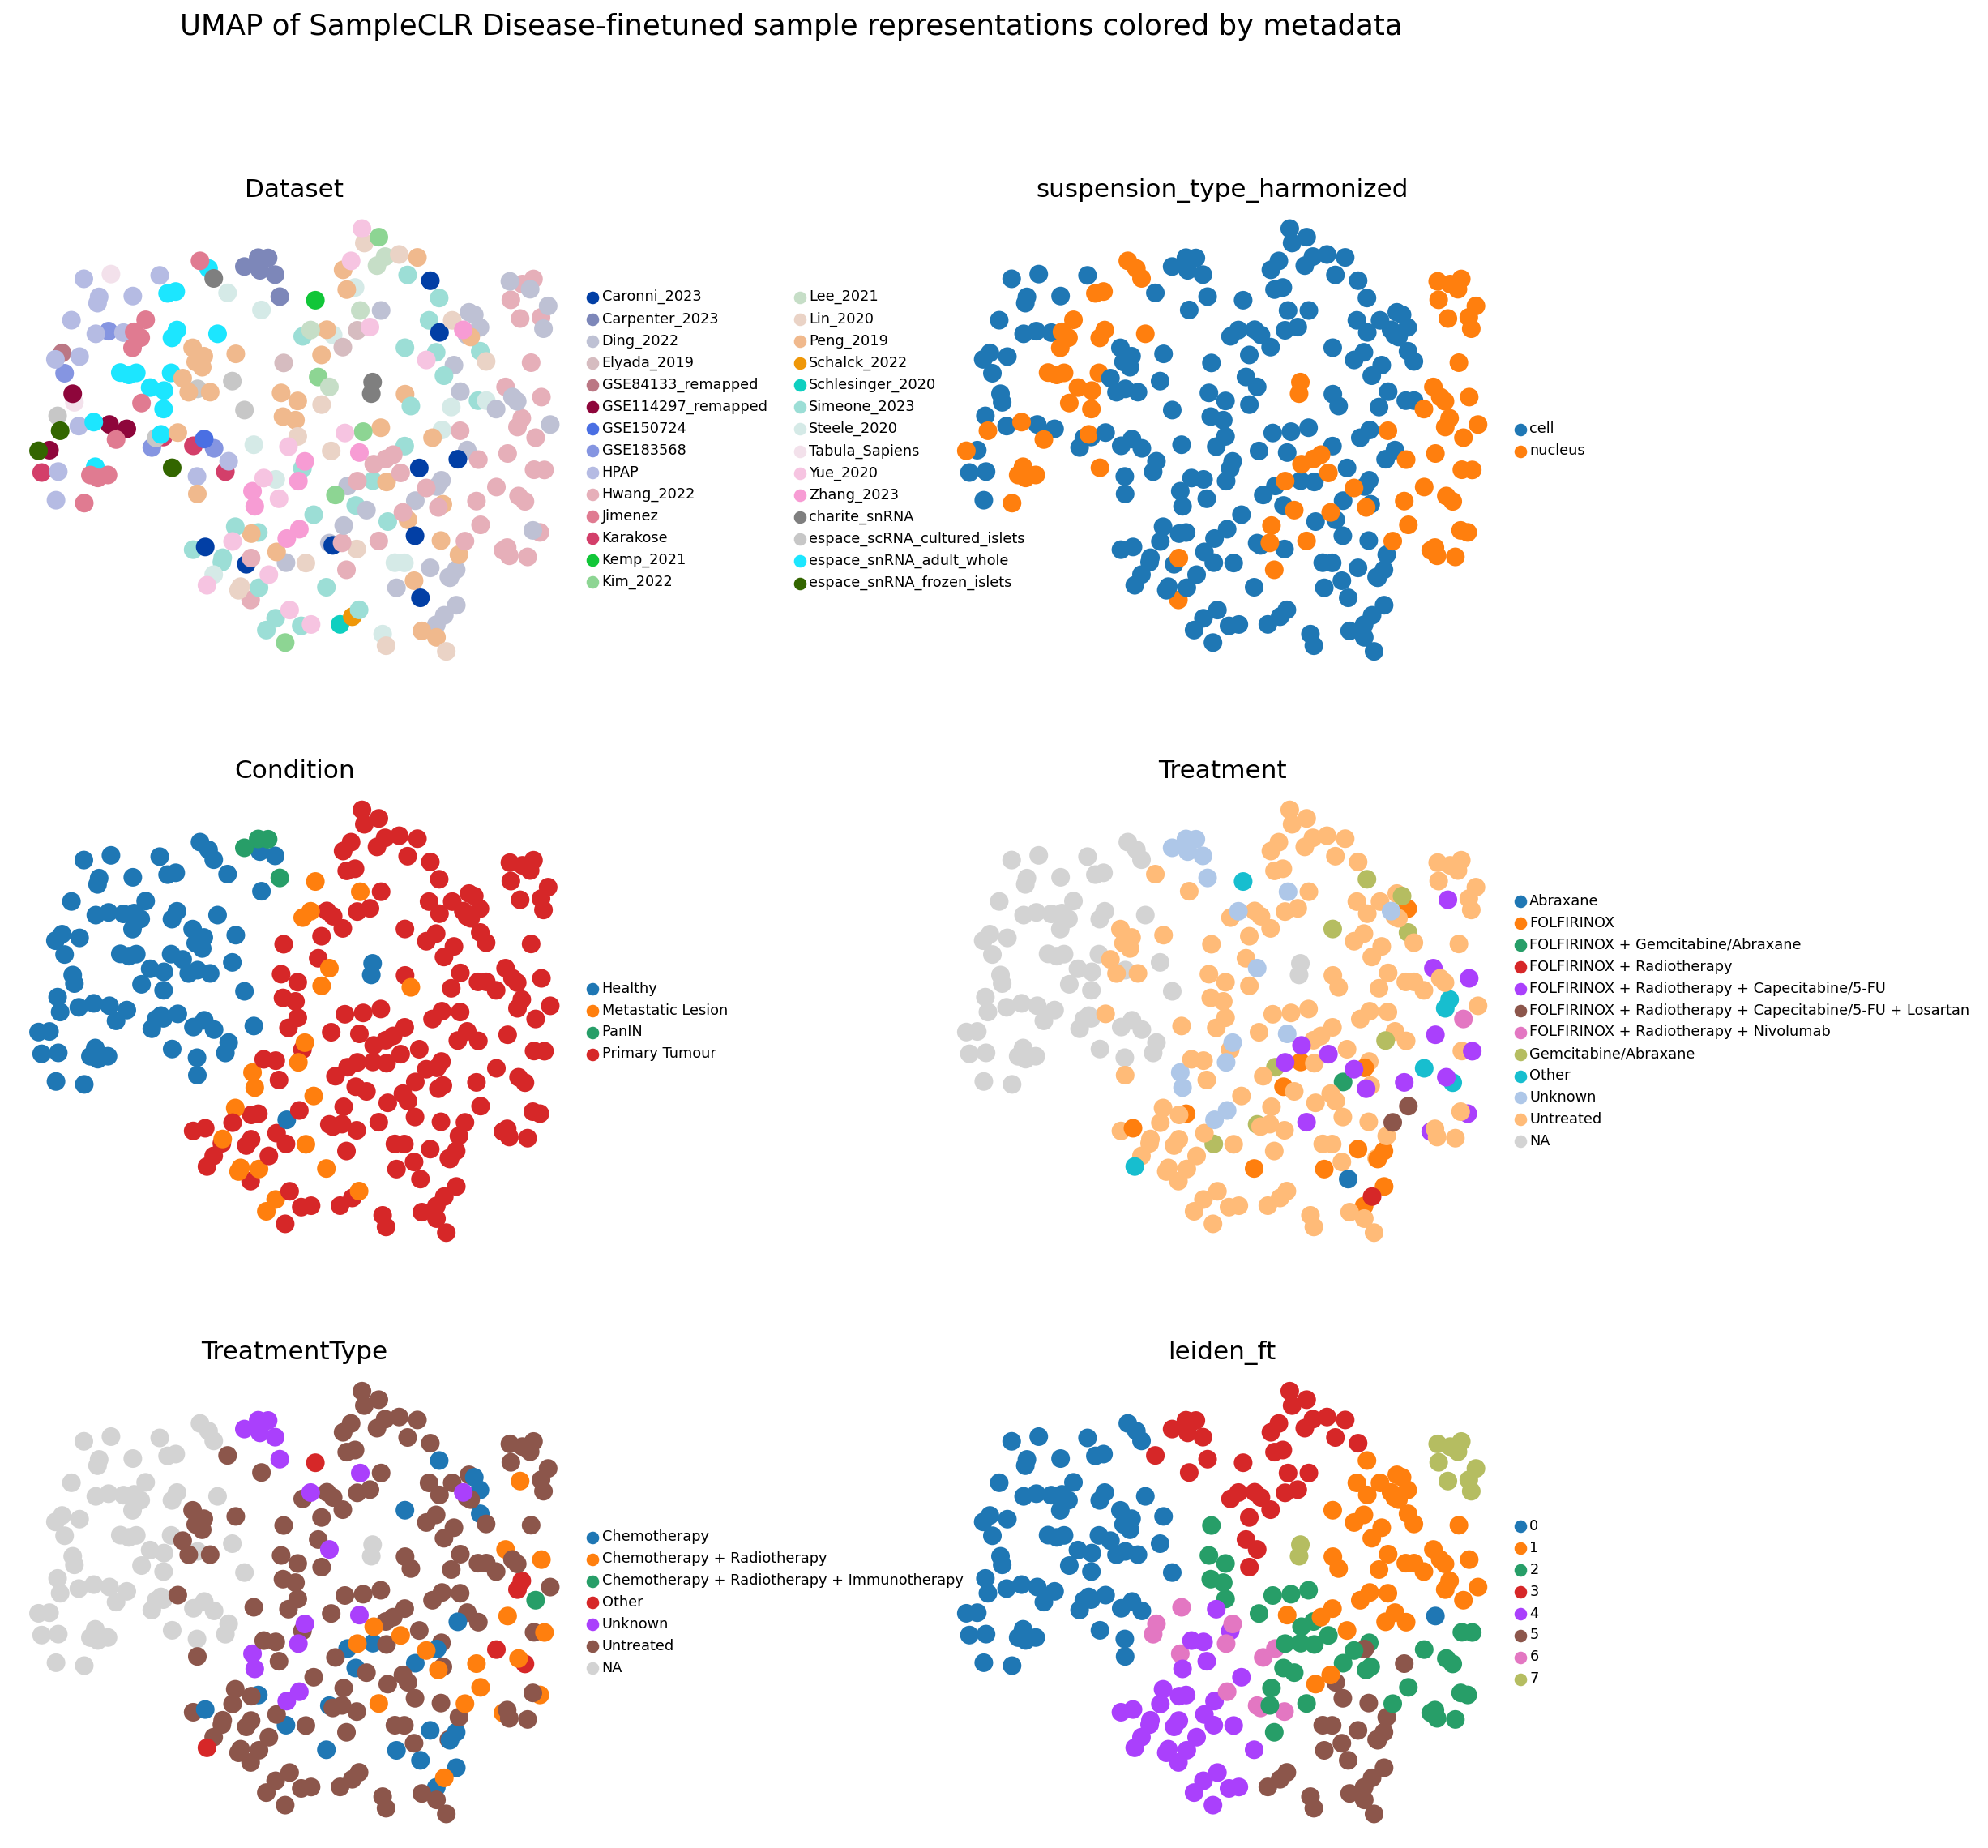

In [30]:
with plt.rc_context({"figure.figsize": (5, 5)}):
    fig = sc.pl.umap(
        meta_adata,
        color=cols_to_plot,
        frameon=False,
        ncols=2,
        return_fig=True,
        # palette="Set3",
        cmap="Reds",
        wspace=0.5, legend_fontsize=8,
    )
    fig.suptitle("UMAP of SampleCLR Disease-finetuned sample representations colored by metadata", fontsize=16)


## 4. Pseudotime Trajectory Inference

We compute two complementary pseudotime measures:
- **Diffusion pseudotime (DPT)** via Scanpy — fast graph-based ordering
- **Palantir pseudotime** — Markov chain model on the diffusion map; handles branching

Both are rooted at a Healthy donor identified from the extremity of the diffusion map.


### 4.1 Inspect Diffusion Map to Choose Root Cell

Visualize all diffusion components to find the component that best separates Healthy from PDAC.


In [33]:
adata.obs['Disease'] = adata.obs.Condition.astype(str).copy()
adata.obs.Disease = adata.obs.Disease.replace('Metastatic Lesion', 'PDAC', regex=True)
adata.obs.Disease = adata.obs.Disease.replace('Primary Tumour', 'PDAC', regex=True)
meta_adata.obs['Disease'] = meta_adata.obs.Condition.astype(str).copy()
meta_adata.obs.Disease = meta_adata.obs.Disease.replace('Metastatic Lesion', 'PDAC', regex=True)
meta_adata.obs.Disease = meta_adata.obs.Disease.replace('Primary Tumour', 'PDAC', regex=True)


In [34]:
# Visualize Diffusion Map and Select Component that makes sense
# sc.pl.diffmap(meta_adata, color=['Condition'], components='all', size=300, legend_fontsize=3, frameon=True)


In [35]:
sc.set_figure_params(dpi=80, figsize=(4,4))


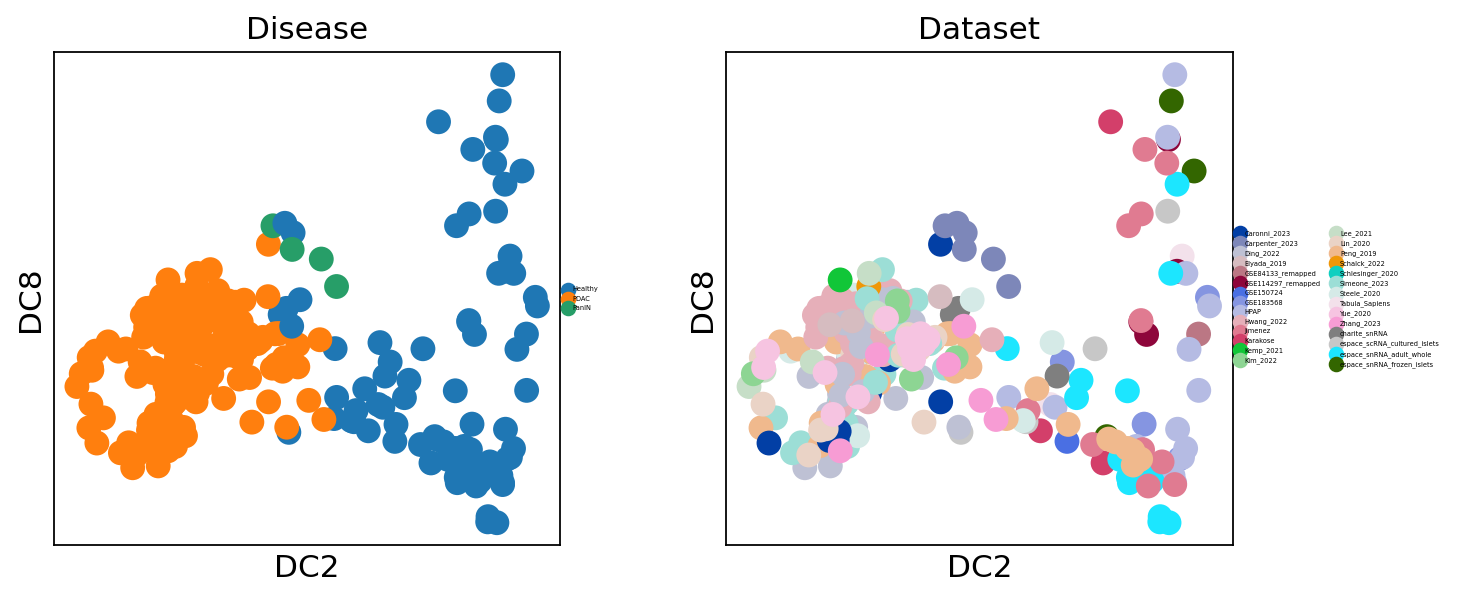

In [39]:
sc.pl.diffmap(meta_adata, color=['Disease', 'Dataset'], components='2,8', size=500, legend_fontsize=3)


### 4.2 Set Root Cell

We root the trajectory at a Healthy donor at the extremity of the diffusion map.  
The root index is stored in `meta_adata.uns['iroot']`.


In [40]:
homeo_cols = [
    "Acinar Cell",
    "Acinar Cell: Digestive Secretion",
    "Acinar Cell: Quiescent",
    "Acinar Cell: Idling",
    "Acinar Cell: CBS",
    "Ductal Cell",
    "Ductal Cell: SLC4A4_pos",
    "Ductal Cell: CFTR Transport",
    "Ductal Cell: Ionocyte Like",
]

perturb_cols = [c for c in meta_adata.var_names if c not in homeo_cols]

homeo = meta_adata[:, homeo_cols].X.sum(axis=1)
perturb = meta_adata[:, perturb_cols].X.sum(axis=1)
meta_adata.obs['homeo_composition'] = homeo
meta_adata.obs['perturb_composition'] = perturb
score = homeo - perturb
meta_adata.obs['root_score'] = score
meta_adata.obs.sort_values('root_score', ascending=False)


,Dataset,sample_id,Condition,condition,manner_of_death,suspension_type,suspension_type_harmonized,technology,assay,Age,...,gene_annotation_version,batch_covar_split,batch_covariate,batch_covar_final,Treatment,TreatmentType,leiden_ft,homeo_composition,perturb_composition,root_score
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
Jimenez : 6229 [Healthy],Jimenez,MM_404,Healthy,Healthy,NaN,nucleus,nucleus,snRNA,10x 3′ v3,NaN,...,NaN,MM_404,NaN,Jimenez,NaN,NaN,0,90.197269,9.802731,80.394537
Jimenez : 6278 [Healthy],Jimenez,MM_400,Healthy,Healthy,NaN,nucleus,nucleus,snRNA,10x 3′ v3,NaN,...,NaN,MM_400,NaN,Jimenez,NaN,NaN,0,85.628187,14.371813,71.256375
espace_snRNA_adult_whole : APSE [Healthy],espace_snRNA_adult_whole,ESPACE-APSE_OD-D4_C_06_B_D1_MA_1,Healthy,Healthy,unknown,nucleus,nucleus,NaN,10x 3′ v3,NaN,...,v98,espace_snRNA_adult_whole_APSE,APSE,espace_snRNA_adult_whole,NaN,NaN,0,83.882995,16.117005,67.765990
Hwang_2022 : T10 [PDAC],Hwang_2022,NaN,Primary Tumour,PDAC,NaN,NaN,nucleus,NaN,NaN,70s,...,NaN,Hwang_2022_T10,NaN,NaN,FOLFIRINOX + Radiotherapy + Capecitabine/5-FU,Chemotherapy + Radiotherapy,0,82.903981,17.096019,65.807963
Jimenez : 6431 [Healthy],Jimenez,MM_381,Healthy,Healthy,NaN,nucleus,nucleus,snRNA,10x 3′ v3,NaN,...,NaN,MM_381,NaN,Jimenez,NaN,NaN,0,80.761365,19.238635,61.522731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Steele_2020_PDAC_TISSUE : 11A [PDAC],Steele_2020,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,Unknown,...,NaN,Steele_2020_PDAC_TISSUE_11A,NaN,NaN,Untreated,Untreated,4,0.000000,100.000000,-100.000000
Lin_2020 : GSM4679541 [PDAC],Lin_2020,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,70s,...,NaN,Lin_2020_GSM4679541,NaN,NaN,Untreated,Untreated,1,0.000000,100.000000,-100.000000
Simeone_2023_GSM6204123 : P15 [PDAC],Simeone_2023,NaN,Primary Tumour,PDAC,NaN,NaN,cell,NaN,NaN,50s,...,NaN,Simeone_2023_GSM6204123_P15,NaN,NaN,Untreated,Untreated,4,0.000000,100.000000,-100.000000


In [41]:
root_cell = 'Jimenez : 6229 [Healthy]'
meta_adata.uns['iroot'] = meta_adata.obs_names.get_loc(root_cell)


In [42]:
meta_adata.obs['root_ixs'] = np.where(meta_adata.obs_names == root_cell, 1.0, np.nan)
meta_adata.obs['Disease_root_ixs'] = meta_adata.obs['Disease'].astype(str) + '_' + meta_adata.obs['root_ixs'].astype(str)
meta_adata.obs['Disease_root_ixs'] = meta_adata.obs['Disease_root_ixs'].replace('_nan','', regex=True)
meta_adata[meta_adata.obs['root_ixs'] == 1.0].obs


,Dataset,sample_id,Condition,condition,manner_of_death,suspension_type,suspension_type_harmonized,technology,assay,Age,...,batch_covariate,batch_covar_final,Treatment,TreatmentType,leiden_ft,homeo_composition,perturb_composition,root_score,root_ixs,Disease_root_ixs
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
Jimenez : 6229 [Healthy],Jimenez,MM_404,Healthy,Healthy,NaN,nucleus,nucleus,snRNA,10x 3′ v3,NaN,...,NaN,Jimenez,NaN,NaN,0,90.197269,9.802731,80.394537,1.0,Healthy_1.0


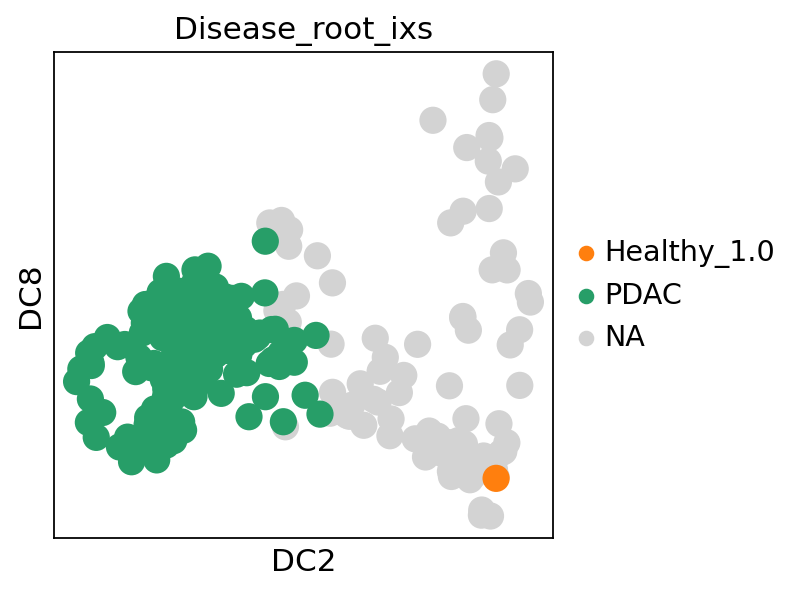

In [43]:
sc.pl.diffmap(meta_adata, color=['Disease_root_ixs'], components='2,8', size=600, groups=['Healthy_1.0', 'PDAC', 'Pancreatitis'])


### 4.3 Diffusion Pseudotime


In [44]:
sc.tl.dpt(meta_adata, neighbors_key='neighbors_sampleclr_ft')


### 4.4 Visualize Pseudotime


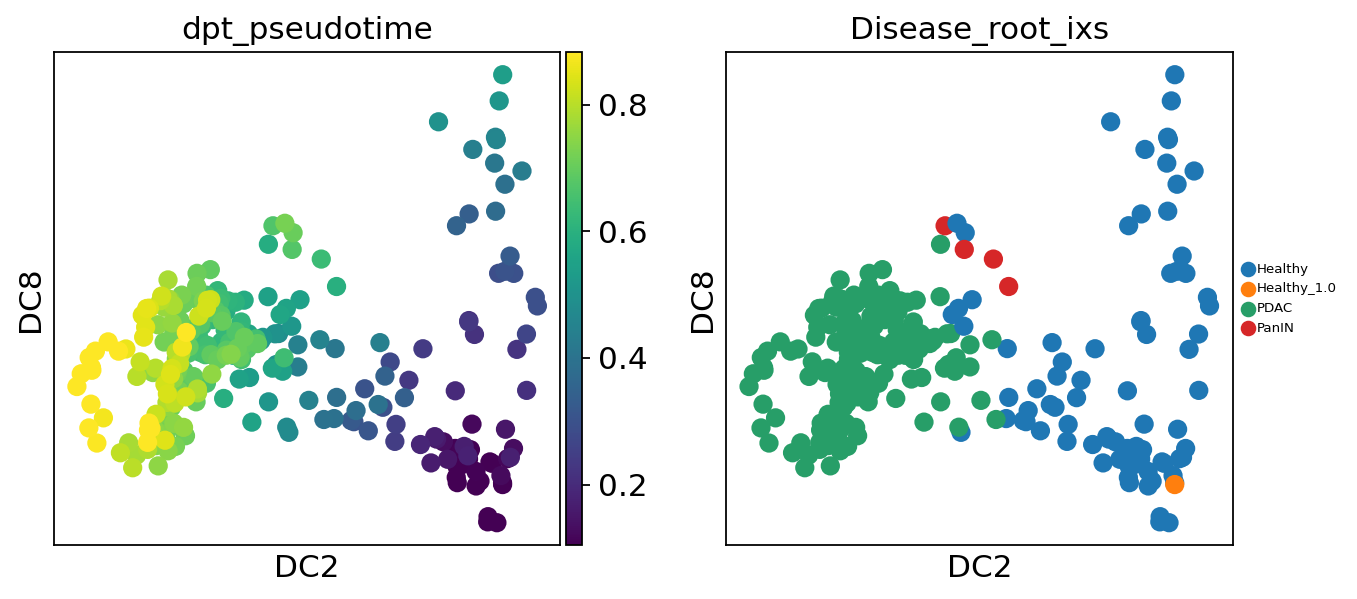

In [47]:
sc.pl.diffmap(meta_adata, color=['dpt_pseudotime', 'Disease_root_ixs'], components=['2,8',], size=300, groups=['PDAC', 'PanIN', 'Healthy_1.0', 'Healthy'], vmax='p95', vmin='p5', legend_fontsize=6)


### 4.5 Cell Attention Weights

Project fine-tuned model attention weights back to individual cells.  
This reveals which cell populations most influence each sample's representation.


In [48]:
weights = get_cell_attention_weights(
    model, adata, sample_key=SAMPLE_KEY, layer=LAYER, device=model.device
)
head_names_ft = [f"SampleCLR_FT_head_{i}" for i in range(weights.shape[1])]


In [49]:
adata.obs[head_names_ft] = weights


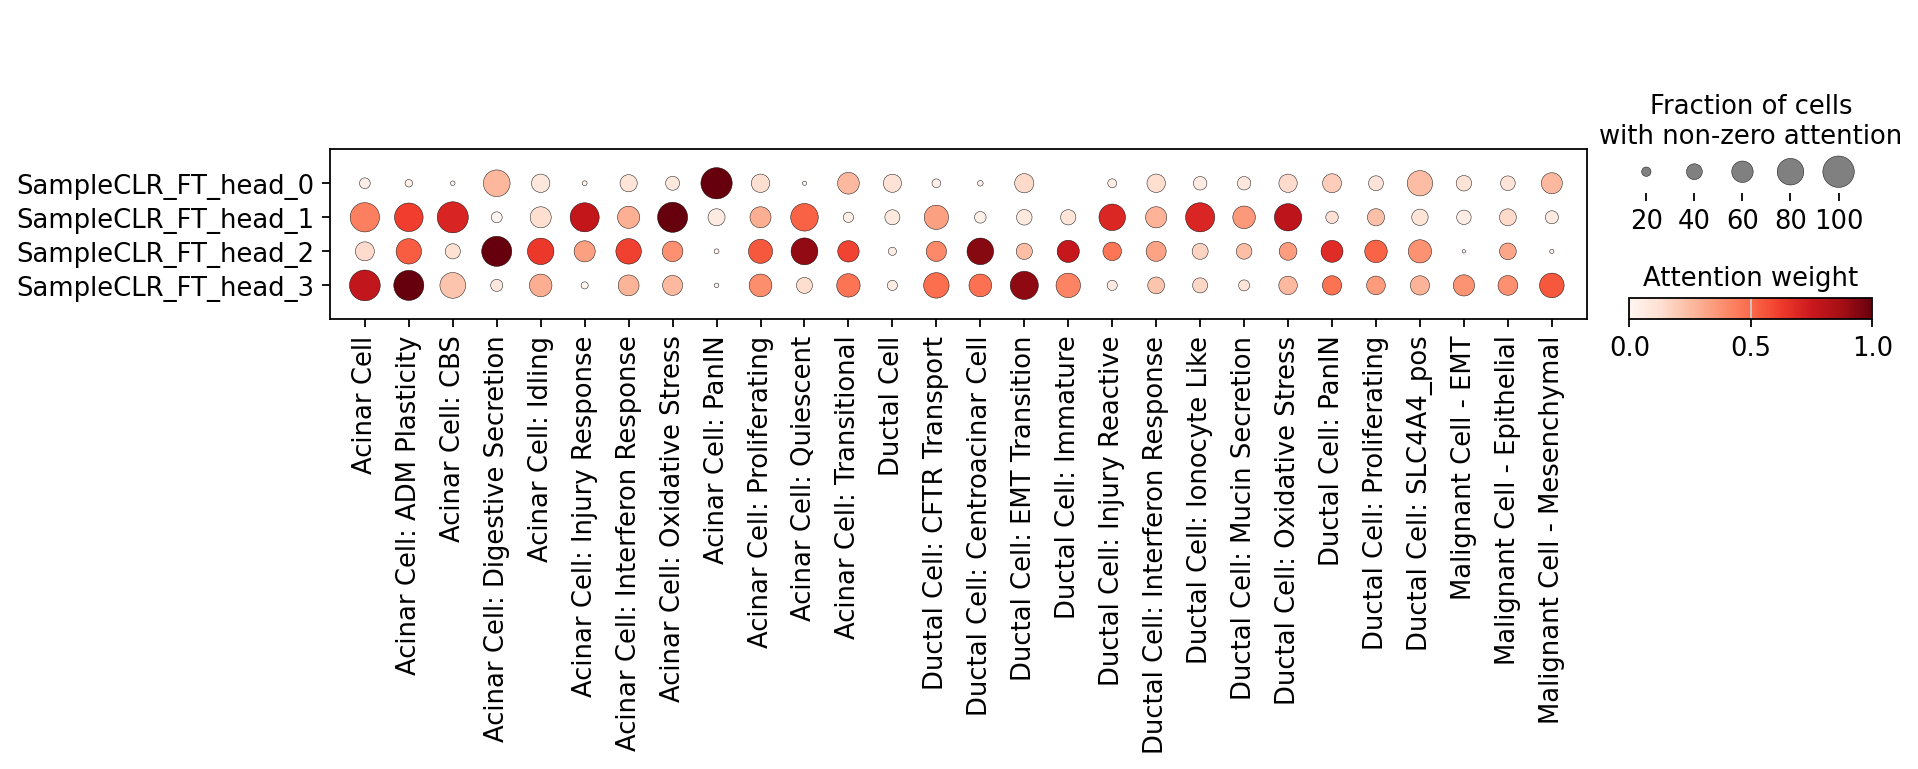

In [50]:
sc.pl.dotplot(
    adata, var_names=head_names_ft, groupby="Final_Labels",
    colorbar_title="Attention weight",
    size_title="Fraction of cells\nwith non-zero attention",
    standard_scale="var", swap_axes=True
)


## 5. Clustering and Defining Regions

We cluster samples in the SampleCLR embedding space using Leiden clustering, summarize connectivity with PAGA, then annotate clusters into three biologically interpretable axes:

| Axis | Biology |
|------|---------|
| **Healthy** | Baseline homeostatic state |
| **Regenerative Remodeling Axis** | Injury and repair-associated programs |
| **Malignant Remodeling Axis** | PDAC-associated transcriptional programs |


### 5.1 Leiden Clustering

In [51]:
sc.tl.leiden(meta_adata, resolution=2, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")


/tmp/ipykernel_270359/3355721983.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(meta_adata, resolution=2, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")


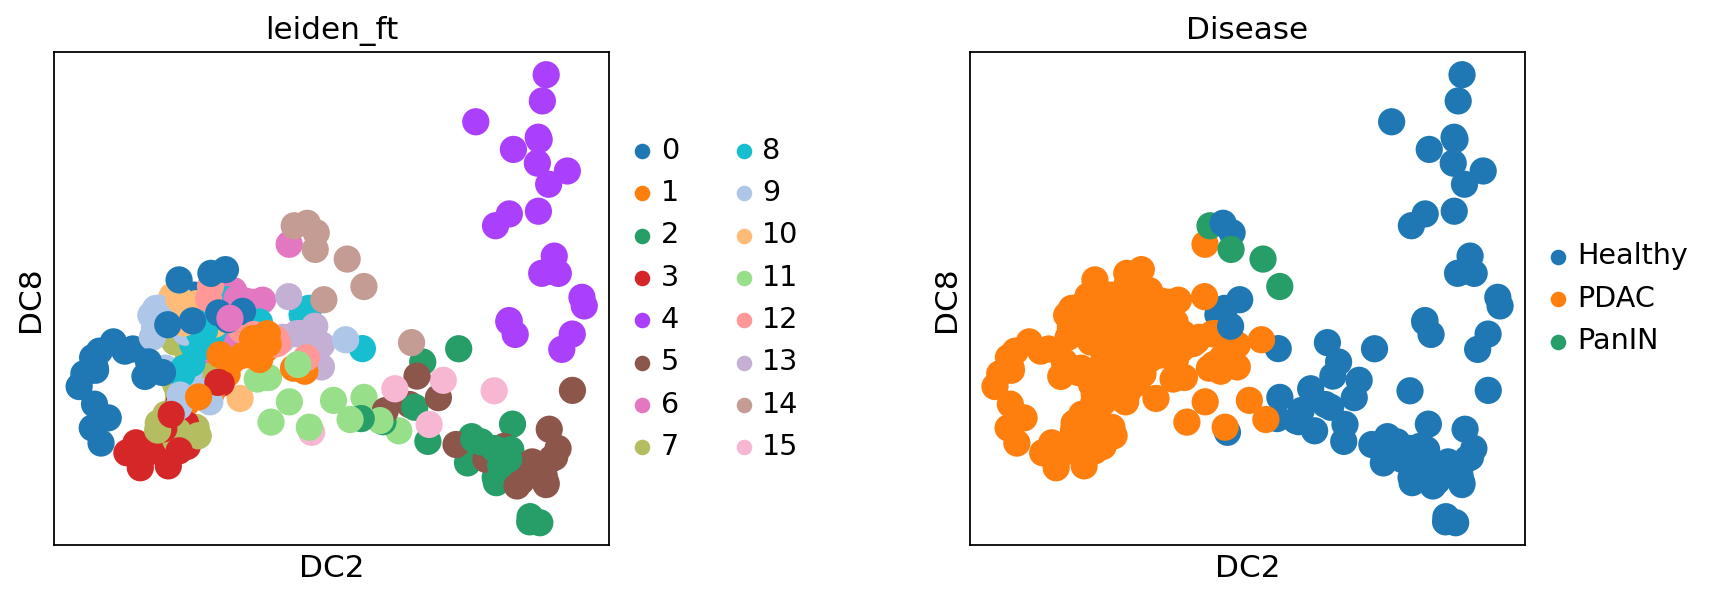

In [52]:
sc.pl.diffmap(meta_adata, color=['leiden_ft', 'Disease'], components='2,8', size=600, wspace=0.5)


In [53]:

# Count number of each Disease per leiden_ft cluster and display as a table
cluster_Disease_counts = (
    meta_adata.obs.groupby(['leiden_ft', 'Condition'])
    .size()
    .unstack(fill_value=0)
)
cluster_Disease_counts


/tmp/ipykernel_270359/412497221.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.obs.groupby(['leiden_ft', 'Condition'])


Condition,Healthy,Metastatic Lesion,PanIN,Primary Tumour
leiden_ft,,,,
0,0,6,0,21
1,0,6,0,19
2,25,0,0,0
3,0,1,0,24
4,23,0,0,0
5,21,0,0,0
6,0,0,0,21
7,0,0,0,20
8,3,0,0,16


### 5.2 PAGA Trajectory Overview

PAGA gives a coarse graph of connectivity between Leiden clusters, useful for trajectory planning.


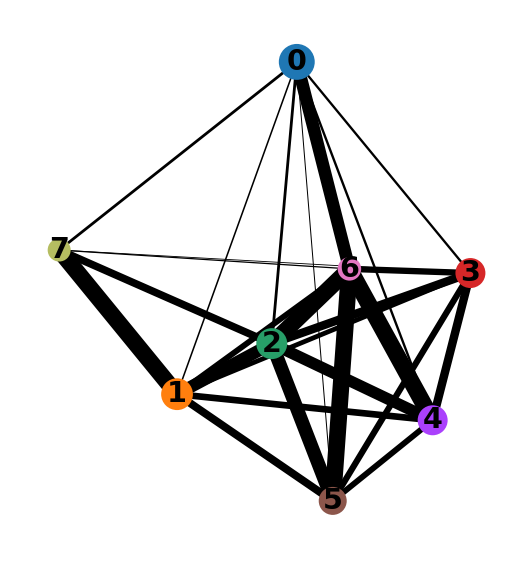

In [ ]:
sc.tl.paga(meta_adata, groups='leiden_ft',  neighbors_key="neighbors_sampleclr_ft")
sc.pl.paga(meta_adata) 

### 5.3 Characterize Clusters by Cell Type Composition


In [54]:
# Compute median, for each leiden_ft, on only variables whose names start with "Acinar" or "Ductal"
acinar_ductal_vars = [v for v in meta_adata.var_names if v.startswith("Acinar") or v.startswith("Ductal")]

# Create a DataFrame containing only the desired columns
df = meta_adata.to_df()[acinar_ductal_vars].copy()

# Add 'leiden_ft' as a column for grouping (ensure not Index alignment but as a column)
df["leiden_ft"] = meta_adata.obs["leiden_ft"].values

acinar_ductal_medians = (
    df
    .groupby("leiden_ft", observed=True)
    .median(numeric_only=True)
)

regeneration_cell_types = [
    'Acinar Cell: Transitional', 'Acinar Cell: ADM Plasticity', 'Acinar Cell: Injury Response', 'Acinar Cell: PanIN',
    'Acinar Cell: Proliferating', 'Ductal Cell: Injury Reactive', 'Ductal Cell: Interferon Response', 'Ductal Cell: PanIN'
]
# Some cell types may be missing in the var_names of this run; filter to existing columns only
existing_regeneration_ct = [ct for ct in regeneration_cell_types if ct in acinar_ductal_medians.columns]
acinar_ductal_medians['Reneration_Fraction'] = acinar_ductal_medians[existing_regeneration_ct].sum(axis=1)
acinar_ductal_medians = acinar_ductal_medians.sort_values('Reneration_Fraction', ascending=False)
acinar_ductal_medians


Final_Labels,Acinar Cell,Acinar Cell: ADM Plasticity,Acinar Cell: CBS,Acinar Cell: Digestive Secretion,Acinar Cell: Idling,Acinar Cell: Injury Response,Acinar Cell: Interferon Response,Acinar Cell: Oxidative Stress,Acinar Cell: PanIN,Acinar Cell: Proliferating,...,Ductal Cell: Immature,Ductal Cell: Injury Reactive,Ductal Cell: Interferon Response,Ductal Cell: Ionocyte Like,Ductal Cell: Mucin Secretion,Ductal Cell: Oxidative Stress,Ductal Cell: PanIN,Ductal Cell: Proliferating,Ductal Cell: SLC4A4_pos,Reneration_Fraction
leiden_ft,,,,,,,,,,,,,,,,,,,,,
4,0.000000,4.633378,0.000000,1.381077,4.248623,3.613735,4.719388,3.239741,0.000000,2.600000,...,0.0,1.960784,1.511879,0.119958,1.129381,0.984683,0.000000,2.439024,0.173010,40.137453
14,1.582444,4.334258,0.693109,12.299721,10.397908,3.771255,0.000000,0.917777,0.000000,0.000000,...,0.0,0.172839,0.000000,0.000000,0.173850,0.957997,0.000000,0.000000,0.000000,24.829028
5,0.709421,3.028869,0.015375,3.523457,27.294686,0.989028,4.347826,2.657359,0.000000,1.644021,...,0.0,0.515607,1.369863,0.116800,0.575971,0.825764,0.000000,0.730768,0.019467,12.768727
2,0.000000,2.362205,0.000000,1.170960,0.276625,0.361882,0.510204,0.719424,0.000000,0.770479,...,0.0,0.753285,1.490075,0.199336,1.149425,2.171291,0.000000,0.739859,0.015731,6.925893
13,0.000000,4.090909,0.000000,0.163666,0.000000,0.445434,0.000000,0.000000,0.000000,0.000000,...,0.0,1.486200,0.000000,0.000000,0.636943,0.116959,0.000000,0.000000,0.000000,6.022543
15,0.000000,0.763359,0.000000,0.152672,0.570465,0.152672,0.246337,0.152672,0.003992,0.324128,...,0.0,2.012056,1.964150,0.246337,1.620823,1.672501,0.000000,0.646732,0.466744,5.294777
9,0.000000,0.107411,0.284168,0.000000,0.524934,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,4.891133,0.000000,0.000000,14.426877,0.262467,0.116460,0.000000,1.513975,5.115004
10,0.000000,0.064392,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.941176,0.000000,0.000000,3.199785,0.000000,0.000000,0.000000,0.000000,1.005568
6,0.000000,0.023838,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.578035,0.000000,0.000000,1.395939,0.041824,0.018734,0.000000,0.000000,0.620606


In [55]:
ct = pd.crosstab(
    meta_adata.obs["leiden_ft"],
    meta_adata.obs["Condition"],
    normalize="index"
) * 100

ct.round(1)


Condition,Healthy,Metastatic Lesion,PanIN,Primary Tumour
leiden_ft,,,,
0,0.0,22.2,0.0,77.8
1,0.0,24.0,0.0,76.0
2,100.0,0.0,0.0,0.0
3,0.0,4.0,0.0,96.0
4,100.0,0.0,0.0,0.0
5,100.0,0.0,0.0,0.0
6,0.0,0.0,0.0,100.0
7,0.0,0.0,0.0,100.0
8,15.8,0.0,0.0,84.2


### 5.4 Define Visualization Axes

Based on cluster composition and pseudotime, we assign each sample to a Visualization Axis.
Clusters enriched for Malignant cell types → Malignant Remodeling Axis.  
Clusters with high regeneration fraction but no malignant cells → Regenerative Remodeling Axis.


In [56]:

meta_adata.obs['Visualization_Axis'] = pd.Series("Healthy", index=meta_adata.obs.index, dtype=object)
meta_adata.obs.loc[
    meta_adata.obs['leiden_ft'].isin(['4']),
    'Visualization_Axis'
] = 'Injury Associated Remodelling'
meta_adata.obs.loc[
    meta_adata.obs['Disease'] == 'PDAC',
    'Visualization_Axis'
] = 'Malignancy Associated Remodelling'

meta_adata.obs['Visualization_Axis'].value_counts()


Visualization_Axis
Malignancy Associated Remodelling    191
Healthy                               66
Injury Associated Remodelling         23
Name: count, dtype: int64

In [57]:
malignant_cell_types = meta_adata.var_names[meta_adata.var_names.str.contains('Malignant')].tolist()


In [58]:
meta_adata.obs['injury_score'] = meta_adata[:, regeneration_cell_types].X.sum(axis=1)
meta_adata.obs['malignant_score'] = meta_adata[:, malignant_cell_types].X.sum(axis=1)


In [62]:
sc.set_figure_params(dpi=80, frameon=False, figsize=(5,5))


### 5.5 Visualize Diffusion Map by Axis

Inspect sample placement on the diffusion map after axis assignment.


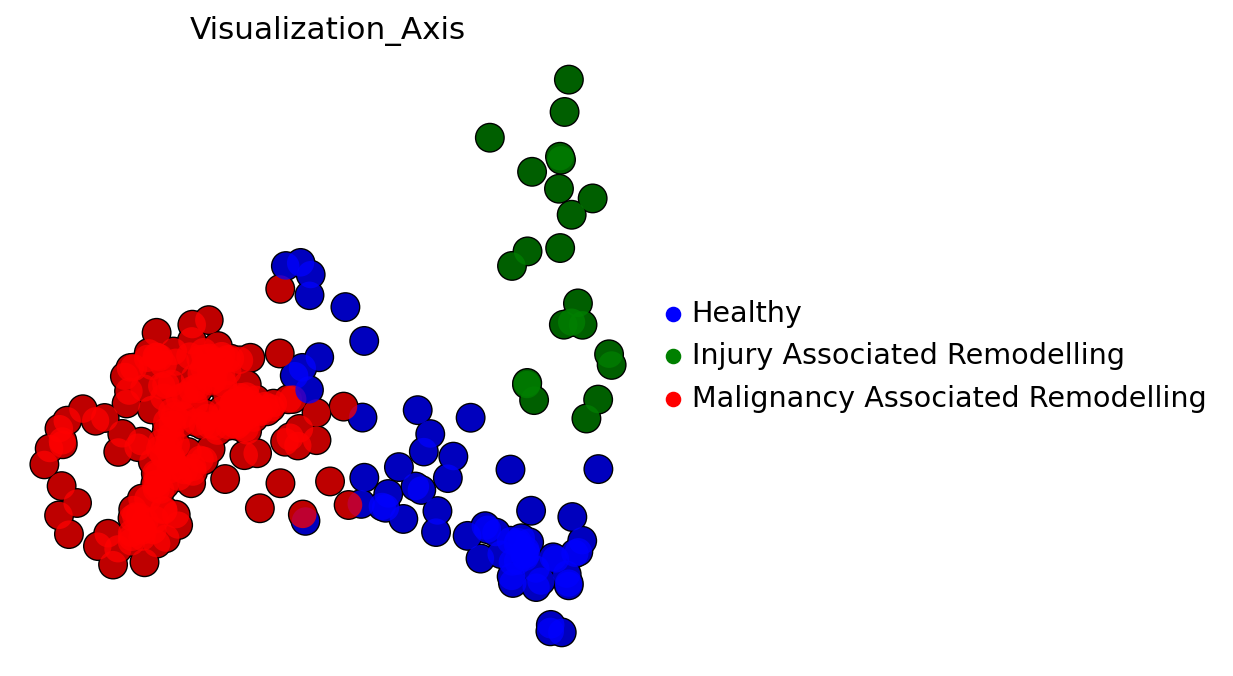

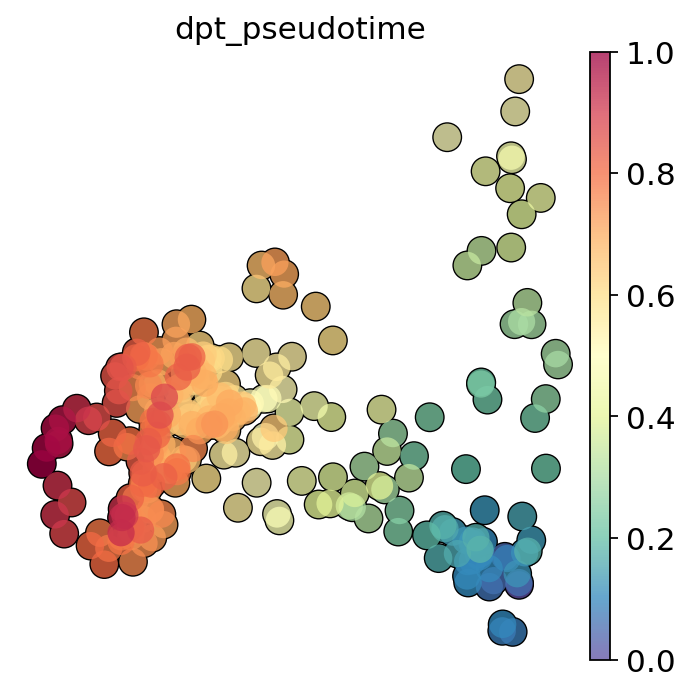

In [63]:
# Define the palette for Visualization_Axis
viz_axis_palette = {
    'Healthy': 'blue',
    'Malignancy Associated Remodelling': 'red',
    'Injury Associated Remodelling': 'green'
}

sc.pl.diffmap(
    meta_adata, components='2,8',
    color=['Visualization_Axis'],
    size=600,
    sort_order=True,
    groups=None,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.05),
    outline_color=['white', 'black'],
    na_color='lightgray',
    alpha=0.75,
    na_in_legend=False,
    palette=viz_axis_palette,

)

sc.pl.diffmap(
    meta_adata, components='2,8',
    color=['dpt_pseudotime'],
    size=600,
    sort_order=True,
    groups=None,
    add_outline=True,
    frameon=False,
    outline_width=(0.1, 0.05),
    outline_color=['white', 'black'],
    na_color='lightgray',
    alpha=0.75,
    na_in_legend=False, cmap='Spectral_r',

)


## 6. Pseudobulk Construction

We aggregate counts from epithelial cells (Acinar, Ductal, Malignant) per sample into a 
**pseudobulk** matrix. This enables gene-level statistical tests with proper sample-level 
replication, avoiding the inflated degrees of freedom of single-cell-level tests.

### 6.1 Pseudobulk Helper Function

Aggregate epithelial cell counts per sample into a pseudobulk matrix.


In [64]:
import numpy as np
import pandas as pd
from scipy import sparse
import anndata as ad
import scanpy as sc

def make_pseudobulk_fast(
    adata_in,
    cell_mask,
    patient_col="Dataset_ID",
    meta_cols=("Dataset", "suspension_type", "Source"),
    count_layer="counts",
    min_cells=0,
    target_sum=1e6,
    store_counts=True,
    dense_output=False,
):
    # Use a view, not a copy
    a = adata_in[cell_mask]

    obs = a.obs
    cell_counts = obs[patient_col].value_counts()

    keep_patients = cell_counts[cell_counts >= min_cells].index
    keep_cells = obs[patient_col].isin(keep_patients).to_numpy()

    # Filter again as a view
    a = a[keep_cells]
    obs = a.obs

    # Pull matrix without densifying
    X = a.layers[count_layer] if count_layer in a.layers else a.X

    if sparse.issparse(X):
        X = X.tocsr()
    else:
        X = np.asarray(X)

    # Encode patient IDs as integer group codes
    patient_ids = pd.Index(obs[patient_col].astype(str))
    patients = pd.Index(pd.unique(patient_ids))
    codes = patients.get_indexer(patient_ids)

    n_patients = len(patients)
    n_cells = X.shape[0]

    # Sparse aggregation matrix: patients x cells
    group_matrix = sparse.csr_matrix(
        (
            np.ones(n_cells, dtype=np.float32),
            (codes, np.arange(n_cells)),
        ),
        shape=(n_patients, n_cells),
    )

    # Pseudobulk counts: patients x genes
    pb_X = group_matrix @ X

    if dense_output and sparse.issparse(pb_X):
        pb_X = pb_X.toarray()

    # Create AnnData
    pb_adata = ad.AnnData(
        X=pb_X.astype(np.float32),
        obs=pd.DataFrame(index=patients),
        var=a.var.copy(),
    )

    # Add metadata
    meta_cols_present = [c for c in meta_cols if c in obs.columns]

    if meta_cols_present:
        patient_meta = (
            obs[[patient_col] + meta_cols_present]
            .drop_duplicates(subset=patient_col)
            .assign(**{patient_col: lambda d: d[patient_col].astype(str)})
            .set_index(patient_col)
        )

        pb_adata.obs = pb_adata.obs.join(patient_meta, how="left")

    pb_adata.obs["n_cells_lineage"] = (
        cell_counts.reindex(pb_adata.obs_names).astype(int).values
    )

    # Store raw pseudobulk counts
    # This duplicates only the small pseudobulk matrix, not the full cell matrix.
    if store_counts:
        pb_adata.layers["counts"] = pb_adata.X.copy()

    # Normalize and log-transform
    sc.pp.normalize_total(pb_adata, target_sum=target_sum)
    sc.pp.log1p(pb_adata)

    return pb_adata


### 6.2 Build Epithelial Pseudobulk

Subset to Acinar, Ductal, and Malignant cells and aggregate counts per donor.


In [65]:
epi_mask = adata.obs.Final_Labels.str.contains('Acinar|Ductal|Malignant')
epi_pb = make_pseudobulk_fast(
    adata,
    epi_mask,
    patient_col="Dataset_ID",
    meta_cols=("Dataset", "suspension_type", "Condition", 
    "Disease", "palantir_pseudotime", "dpt_pseudotime", "suspension_type_harmonized"
    "Treatment", "TreatmentType"),
    count_layer="counts",
)


### 6.3 Filter Uninformative Genes

Remove mitochondrial, ribosomal, hemoglobin, LINC, and unannotated genes.


In [66]:
bad_gene_mask = (
    epi_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB", "LINC"))
    | epi_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
)
print(len(epi_pb.var_names[bad_gene_mask]))
epi_pb.var_names[bad_gene_mask]
# ----- cell boundary -----
import re
print(f'Genes before filtering: {len(epi_pb.var_names)}')
sc.pp.filter_genes(epi_pb, min_cells=5)
# Re-apply filter to remove MT, RPL, RPS, HB, LINC and A[X]-type genes after filtering low-abundance genes
bad = (
    epi_pb.var_names.str.startswith(("MT", "RPL", "RPS", "HB", "LINC"))
    | epi_pb.var_names.str.match(r"^A[A-Z]\d+(\.\d+)?$")
)
epi_pb = epi_pb[:, ~bad].copy()
print(f'Genes after filtering: {len(epi_pb.var_names)}')


1721
Genes before filtering: 21730
Genes after filtering: 19891


In [67]:
epi_pb.obs['suspension_type_harmonized'] = epi_pb.obs_names.map(dict(zip(meta_adata.obs_names, meta_adata.obs.suspension_type_harmonized)))
epi_pb.obs['dpt_pseudotime'] = epi_pb.obs_names.map(dict(zip(meta_adata.obs_names, meta_adata.obs.dpt_pseudotime)))


### 6.4 Align Pseudobulk with Sample Metadata

Attach diffusion-map coordinates and restrict pseudobulk to samples in `meta_adata`.


In [68]:
meta_adata.obsm['X_dm28'] = meta_adata.obsm['X_diffmap'][:,[1 ,7]].copy()


In [69]:
epi_pb = epi_pb[meta_adata.obs_names]


In [70]:
epi_pb.obsm['X_dm28'] = meta_adata.obsm['X_dm28'].copy()
epi_pb.obs['Visualization_Axis'] = meta_adata.obs['Visualization_Axis'].copy()


/tmp/ipykernel_270359/1490759712.py:1: ImplicitModificationWarning: Setting element `.obsm['X_dm28']` of view, initializing view as actual.
  epi_pb.obsm['X_dm28'] = meta_adata.obsm['X_dm28'].copy()


## 7. Gene–Pseudotime Correlations

We test genes for significant linear association with branch-specific DPT pseudotime, controlling for suspension type (sc vs. sn RNA). Genes with significant positive or negative correlations define the transcriptional programs along each remodeling axis.


### 7.1 Define Branch DPT Gene Test

Fit linear models of gene expression along branch-specific pseudotime, adjusting for covariates.


In [77]:
def branch_dpt_gene_test(
    pb_adata,
    branch_sources,
    time_col="dpt_pseudotime",
    Disease_col="Disease",
    covariates=("age_category", "suspension_type"),
):
    pb = pb_adata[pb_adata.obs[Disease_col].isin(branch_sources)].copy()
    X = pb.X.toarray() if sparse.issparse(pb.X) else np.asarray(pb.X)
    obs = pb.obs.copy()
    obs[time_col] = pd.to_numeric(obs[time_col], errors="coerce")
    usable_covs = [c for c in covariates if c in obs.columns]
    design = pd.DataFrame(index=obs.index)
    design[time_col] = obs[time_col].astype(float)
    for cov in usable_covs:
        if obs[cov].dtype.name in ["category", "object"]:
            dummies = pd.get_dummies(obs[cov], prefix=cov, drop_first=True)
            design = pd.concat([design, dummies], axis=1)
        else:
            design[cov] = pd.to_numeric(obs[cov], errors="coerce")
    results = []
    for j, gene in tqdm(list(enumerate(pb.var_names)), desc=f"Branch model {branch_sources}"):
        df = design.copy()
        df["expr"] = X[:, j].astype(float)
        df = df.dropna()
        try:
            y = df["expr"].values
            X_design = df.drop(columns=["expr"])
            X_design = sm.add_constant(X_design).astype(float)
            fit = sm.OLS(y, X_design).fit()
            coef = fit.params[time_col]
            pval = fit.pvalues[time_col]
            r2 = fit.rsquared
            results.append((gene, coef, pval, df.shape[0], r2))
        except Exception:
            results.append((gene, np.nan, np.nan, df.shape[0], np.nan))
    res = pd.DataFrame(
        results,
        columns=["gene", "dpt_coef", "dpt_pval", "n", "r2"]
    )
    res["dpt_padj"] = multipletests(res["dpt_pval"].fillna(1.0), method="fdr_bh")[1]
    res["score"] = -np.log10(res["dpt_padj"].clip(lower=1e-300)) * res["dpt_coef"]
    return res.sort_values("dpt_padj", na_position="last")


### 7.2 Run Branch-Specific Gene Tests

Test genes along the Regenerative and Malignant remodeling branches separately.


In [79]:
injury_branch = branch_dpt_gene_test(
    epi_pb,
    branch_sources=[
        "Healthy",
        "Injury Associated Remodelling"],
    Disease_col="Visualization_Axis",
    covariates=("suspension_type_harmonized",))


Branch model ['Healthy', 'Injury Associated Remodelling']:   3%|▎         | 576/19891 [00:01<00:33, 571.91it/s]/opt/scanpy_venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Branch model ['Healthy', 'Injury Associated Remodelling']:   6%|▋         | 1271/19891 [00:02<00:32, 572.41it/s]/opt/scanpy_venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Branch model ['Healthy', 'Injury Associated Remodelling']:   9%|▉         | 1791/19891 [00:03<00:31, 572.93it/s]/opt/scanpy_venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Branch model ['Healthy', 'Injury Associated Remodelling']:  15%|█▌        | 3009/19891 [00:05<0

In [80]:
pdac_branch = branch_dpt_gene_test(
    epi_pb,
    branch_sources=["Healthy",
        "Malignancy Associated Remodelling"],
    Disease_col="Visualization_Axis",
    covariates=("suspension_type_harmonized",))


Branch model ['Healthy', 'Malignancy Associated Remodelling']: 100%|██████████| 19891/19891 [00:35<00:00, 559.08it/s]


### 7.3 Extract Branch Gene Sets

Select up- and down-regulated genes for each branch using adjusted p-value and coefficient thresholds.


In [81]:
def get_branch_genes(res, direction="up", padj_thresh=0.05, coef_thresh=0.25, n=100):
    x = res.copy()
    x = x[x["dpt_padj"] < padj_thresh]

    if direction == "up":
        x = x[x["dpt_coef"] > coef_thresh]
        x = x.sort_values(["score", "dpt_coef"], ascending=[False, False])
    elif direction == "down":
        x = x[x["dpt_coef"] < -coef_thresh]
        x = x.sort_values(["score", "dpt_coef"], ascending=[True, True])
    else:
        raise ValueError("direction must be 'up' or 'down'")

    return x.head(n)


In [82]:
injury_up = get_branch_genes(injury_branch, "up")
injury_down = get_branch_genes(injury_branch, "down")
pdac_up = get_branch_genes(pdac_branch, "up")
pdac_down = get_branch_genes(pdac_branch, "down")


In [83]:
pdac_up.head(20)


,gene,dpt_coef,dpt_pval,n,r2,dpt_padj,score
14532,S100P,7.041231,1.978012e-36,257,0.600247,2.459040e-33,229.609157
17481,TMPRSS4,6.042415,9.638153e-40,257,0.501629,3.834250e-36,214.000114
2240,CAPN8,5.617013,9.033388e-40,257,0.504148,3.834250e-36,198.933940
6838,GPRC5A,5.651314,7.258111e-39,257,0.504039,1.804638e-35,196.347043
8449,KCNN4,5.156122,4.478951e-43,257,0.549252,8.909082e-39,196.191317
12047,PCDH7,5.250030,1.230174e-39,257,0.544813,4.078232e-36,185.796098
5909,FHL2,4.827256,3.965814e-42,257,0.545490,3.944200e-38,180.558874
808,ANXA1,5.228470,5.340680e-36,257,0.558439,4.828703e-33,168.964127
5284,ERN2,4.652140,2.827613e-37,257,0.476349,4.326465e-34,155.213388
18933,XAF1,4.554254,9.547241e-38,257,0.478278,1.582535e-34,153.936722


In [84]:
injury_up.head(20)


,gene,dpt_coef,dpt_pval,n,r2,dpt_padj,score
13973,REG3A,5.403413,6.769989e-05,89,0.302665,0.016422,9.642765
8417,KCNJ5,2.296395,1.473554e-07,89,0.698810,0.002063,6.167130
9011,LGALS2,2.738076,1.720445e-05,89,0.257033,0.007530,5.813532
2010,C3,2.970429,3.136883e-05,89,0.250638,0.011142,5.801347
9687,MAT1A,2.245502,1.787311e-06,89,0.569200,0.002963,5.677357
17102,TIPARP-AS1,1.959566,2.081532e-07,89,0.393238,0.002063,5.262551
13428,PTF1A,2.532311,2.993853e-05,89,0.333709,0.010909,4.968946
13467,PTP4A3,2.005566,1.947476e-05,89,0.204852,0.008241,4.179611
9245,LRP4,1.940120,1.741337e-05,89,0.776670,0.007530,4.119299
8617,KIRREL2,1.899662,1.286089e-05,89,0.620656,0.007046,4.088159


### 7.4 Branch Gene Overlap

Identify genes shared between branches versus branch-specific programs.


In [85]:
shared_up = set(injury_up["gene"]) & set(pdac_up["gene"])
injury_specific_up = set(injury_up["gene"]) - set(pdac_up["gene"])
pdac_specific_up = set(pdac_up["gene"]) - set(injury_up["gene"])
shared_down = set(injury_down["gene"]) & set(pdac_down["gene"])
injury_specific_down = set(injury_down["gene"]) - set(pdac_down["gene"])
pdac_specific_down = set(pdac_down["gene"]) - set(injury_down["gene"])


### 7.5 Program Scores by Visualization Axis

Summarize remodeling program scores across assigned visualization axes.


In [86]:
meta_adata.to_df().groupby(meta_adata.obs['Visualization_Axis']).median().T


/tmp/ipykernel_270359/1321887300.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meta_adata.to_df().groupby(meta_adata.obs['Visualization_Axis']).median().T


Visualization_Axis,Healthy,Injury Associated Remodelling,Malignancy Associated Remodelling
Final_Labels,,,
Acinar Cell,0.041010,0.000000,0.000000
Acinar Cell: ADM Plasticity,2.717645,4.633378,0.000000
Acinar Cell: CBS,0.012478,0.000000,0.000000
Acinar Cell: Digestive Secretion,2.209332,1.381077,0.000000
Acinar Cell: Idling,4.364701,4.248623,0.000000
Acinar Cell: Injury Response,0.772677,3.613735,0.000000
Acinar Cell: Interferon Response,2.515823,4.719388,0.000000
Acinar Cell: Oxidative Stress,1.413264,3.239741,0.000000
Acinar Cell: PanIN,0.000000,0.000000,0.000000


### 7.6 Summarize Branch Genes

Collect branch-specific and shared gene lists into a summary table.


In [87]:
df_branch_genes = pd.DataFrame.from_dict({
    "injury_up": injury_up.gene.tolist(),
    "injury_down": injury_down.gene.tolist(),
    "pdac_up": pdac_up.gene.tolist(),
    "pdac_down": pdac_down.gene.tolist(),
    "shared_up": shared_up,
    "injury_specific_up": injury_specific_up,
    "pdac_specific_up": pdac_specific_up,
    "shared_down": shared_down,
    "injury_specific_down": injury_specific_down,
    "pdac_specific_down": pdac_specific_down,
}, orient="index").T
df_branch_genes.head(30)


,injury_up,injury_down,pdac_up,pdac_down,shared_up,injury_specific_up,pdac_specific_up,shared_down,injury_specific_down,pdac_specific_down
0,REG3A,PPP2CA,S100P,CLPS,None,C2orf66,IRAK3,ELAC1,DNAJB6,CTNND2
1,KCNJ5,CRYZL1,TMPRSS4,CPA1,None,COX6A2,MBOAT2,None,SAR1A,CTRB2
2,LGALS2,SLF1,CAPN8,CTRB1,None,TBX20,APOL1,None,DDX19B,EGF
3,C3,MED26,GPRC5A,PLA2G1B,None,RNF186,CTSE,None,IRS2,NIBAN1
4,MAT1A,TMEM14B,KCNN4,PNLIP,None,REG3A,LRP1,None,CDS2,SYCN
5,TIPARP-AS1,RAB5C,PCDH7,CTRC,None,TMEM44-AS1,BATF,None,SLF1,MYRIP
6,PTF1A,SDHAF2,FHL2,CELA3A,None,LAMA1,TSPAN1,None,PROSER3,CPA1
7,PTP4A3,TERF2IP,ANXA1,CTRB2,None,TNFSF14,ECM1,None,ZNF544,PRSS2
8,LRP4,ELAC1,ERN2,CPA2,None,THPO,BCAS1,None,MOB4,SCGN
9,KIRREL2,PMF1,XAF1,CELA3B,None,RAPGEFL1,PTPRE,None,RAB5C,INS


#### End